In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn, optim

from transformer.vocabs import get_or_create_smiles_vocabs
from transformer.data_funcs import calculate_max_mz
from transformer.transformer_utils import split_and_load_tokenized_multimodal_data
from transformer.data_funcs import bin_spectrum
from transformer.models import MultimodalVITSeq2SeqBeam
from transformer.sequence_pred import train_multimodal_beam_model
from transformer.evaluation import evaluate_multimodal_beam_model, plot_training_history

In [2]:
if torch.cuda.is_available():
    print("CUDA is available.")
    print("PyTorch version:", torch.__version__)
    print("CUDA version:", torch.version.cuda)
    print("Number of available GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available.")

CUDA is available.
PyTorch version: 2.0.1+cu118
CUDA version: 11.8
Number of available GPUs: 1
GPU name: NVIDIA GeForce RTX 3080


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
ir = pd.read_feather('data/ir_spectra_v2.feather')
ir.columns= ['SMILES', 'spectrum']

In [5]:
ir.head()

,SMILES,spectrum
0,COc1nc2ccccc2cc1C(=O)O,"[-0.004481, 0.007279, -0.006439, 0.007464, -0...."
1,CCOC(=O)c1cc2c(OCc3coc4cc(F)ccc34)cccc2n1C(=O)...,"[0.028195, 0.011433, 0.024865, -0.00816, 0.055..."
2,CCCCOc1c(CN2C(=O)c3ccccc3C2=O)n(CC2CC2)c(=O)c2...,"[-0.003043, 0.014693, -0.003067, 0.025262, -0...."
3,CCCCNC[C@@H]1O[C@](O)(CO)[C@@H](O)[C@@H]1O,"[0.099321, 0.155452, 0.048156, 0.19118, 0.0237..."
4,O=C(NCC1CC1)c1nc2c(N3CCC(n4c(=O)[nH]c5ccccc54)...,"[0.2335, 0.090925, 0.061724, 0.158822, 0.04248..."


In [6]:
ms = pd.read_feather('data/msms_cfmid_positive_40ev_v2.feather')
ms.columns = ['SMILES', 'spectrum']

In [7]:
ms.head()

,SMILES,spectrum
0,COc1nc2ccccc2cc1C(=O)O,"[[101.03858, 100.0], [103.05423, 43.72], [104...."
1,CCOC(=O)c1cc2c(OCc3coc4cc(F)ccc34)cccc2n1C(=O)...,"[[57.06988, 51.14], [91.05423, 9.59], [121.044..."
2,CCCCOc1c(CN2C(=O)c3ccccc3C2=O)n(CC2CC2)c(=O)c2...,"[[57.06988, 28.12], [105.03349, 100.0], [117.0..."
3,CCCCNC[C@@H]1O[C@](O)(CO)[C@@H](O)[C@@H]1O,"[[30.03383, 36.99], [41.03858, 8.43], [42.0338..."
4,O=C(NCC1CC1)c1nc2c(N3CCC(n4c(=O)[nH]c5ccccc54)...,"[[55.05423, 63.08], [70.02874, 18.67], [70.065..."


In [8]:
# Minimal test
n = 50000
df_ir = ir.sample(n)
df_ir_test = ir.drop(index=df_ir.index).sample(n//2)
df_ms = ms.loc[df_ir.index]
df_ms_test = ms.loc[df_ir_test.index]

In [9]:
df_ir.reset_index(drop=True, inplace=True)
df_ir_test.reset_index(drop=True, inplace=True)
df_ms.reset_index(drop=True, inplace=True)
df_ms_test.reset_index(drop=True, inplace=True)

In [10]:
method='direct'

In [11]:
smiles_vocabs = get_or_create_smiles_vocabs(pd.concat([ms, ir]), smiles_col='SMILES', source='msd')

Loading existing character vocabulary...
SMILES vocabulary size (character): 39
Loading existing atom_wise vocabulary...
SMILES vocabulary size (atom_wise): 14
Loading existing substructure vocabulary...
SMILES vocabulary size (substructure): 3767143


In [12]:
max_mz = calculate_max_mz(pd.concat([df_ms, df_ms_test]), spectrum_column='spectrum', dtype=np.array)

In [13]:
max_ir = ir['spectrum'].apply(lambda x: len(x)).max()

In [14]:
train_data = {
    'MS': df_ms,
    'IR': df_ir
}
test_data = {
    'MS': df_ms_test,
    'IR': df_ir_test
}
tokenization_methods = {
    'MS': 'direct',
    'IR': 'direct'
}
max_values = {
    'MS': max_mz,
    'IR': max_ir
}

In [15]:
df_ms['spectrum'] = df_ms['spectrum'].apply(lambda x: bin_spectrum(x, max_mz))
df_ms_test['spectrum'] = df_ms_test['spectrum'].apply(lambda x: bin_spectrum(x, max_mz))

In [16]:
results = {}
for key, value in tokenization_methods.items():
    print(f"\n{key} spectra tokenized with {value} tokenization")
print(f"\nSMILES tokenized with {'character'} tokenization")
smiles_vocab = smiles_vocabs['character']

train_loader, test_loader = split_and_load_tokenized_multimodal_data(
    train_data_dict=train_data,
    train_smiles=df_ms['SMILES'],
    test_data_dict=test_data,
    test_smiles=df_ms_test['SMILES'],
    tokenization_methods=tokenization_methods,
    smiles_vocab=smiles_vocabs['character'],
    max_values=max_values,
)

#num_classes = len(label_encoder.classes_)
smiles_vocab_size = len(smiles_vocab)

# sample batch used for input dimensions
sample_batch, target_batch = next(iter(train_loader))
for key in tokenization_methods.keys():
    print(key, "spectra shape:", sample_batch[key].shape)
print("SMILES shape:", target_batch.shape)
embed_depth = sample_batch['MS'].shape[3]


MS spectra tokenized with direct tokenization

IR spectra tokenized with direct tokenization

SMILES tokenized with character tokenization
MS spectra shape: torch.Size([32, 1, 60, 16])
IR spectra shape: torch.Size([32, 1, 113, 16])
SMILES shape: torch.Size([32, 93])


In [17]:
modality_configs = {
    'MS': {
        'embed_depth': 16,
        'max_length': sample_batch['MS'].shape[2],
    },
    'IR': {
        'embed_depth': 16,
        'max_length': sample_batch['IR'].shape[2],
    }
}

In [18]:
model = MultimodalVITSeq2SeqBeam(
    smiles_vocab_size=len(smiles_vocab),
    modality_configs=modality_configs,
    d_model=64,             # 256
    nhead=4,                # 8
    num_layers=2,           # 6
    dim_feedforward=256,    # 2048
)

In [19]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()#ignore_index=smiles_vocab['<pad>'])

model, history = train_multimodal_beam_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=50,
    evaluate=False,
    verbose=2,
    checkpoint_path='model_checkpoints/',
    use_tensorboard=True,
)

TensorBoard logs will be saved to runs/20250116-121928
Saving checkpoints to model_checkpoints/checkpoint_8


Epoch 1/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 3/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 4/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Epoch 46/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 47/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 48/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 49/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

In [20]:
results = evaluate_multimodal_beam_model(
    model=model, 
    test_loader=test_loader, 
    smiles_vocab=smiles_vocab, 
    beam_width=5,
    verbose=1
)

Evaluating:   0%|          | 0/782 [00:00<?, ?it/s]

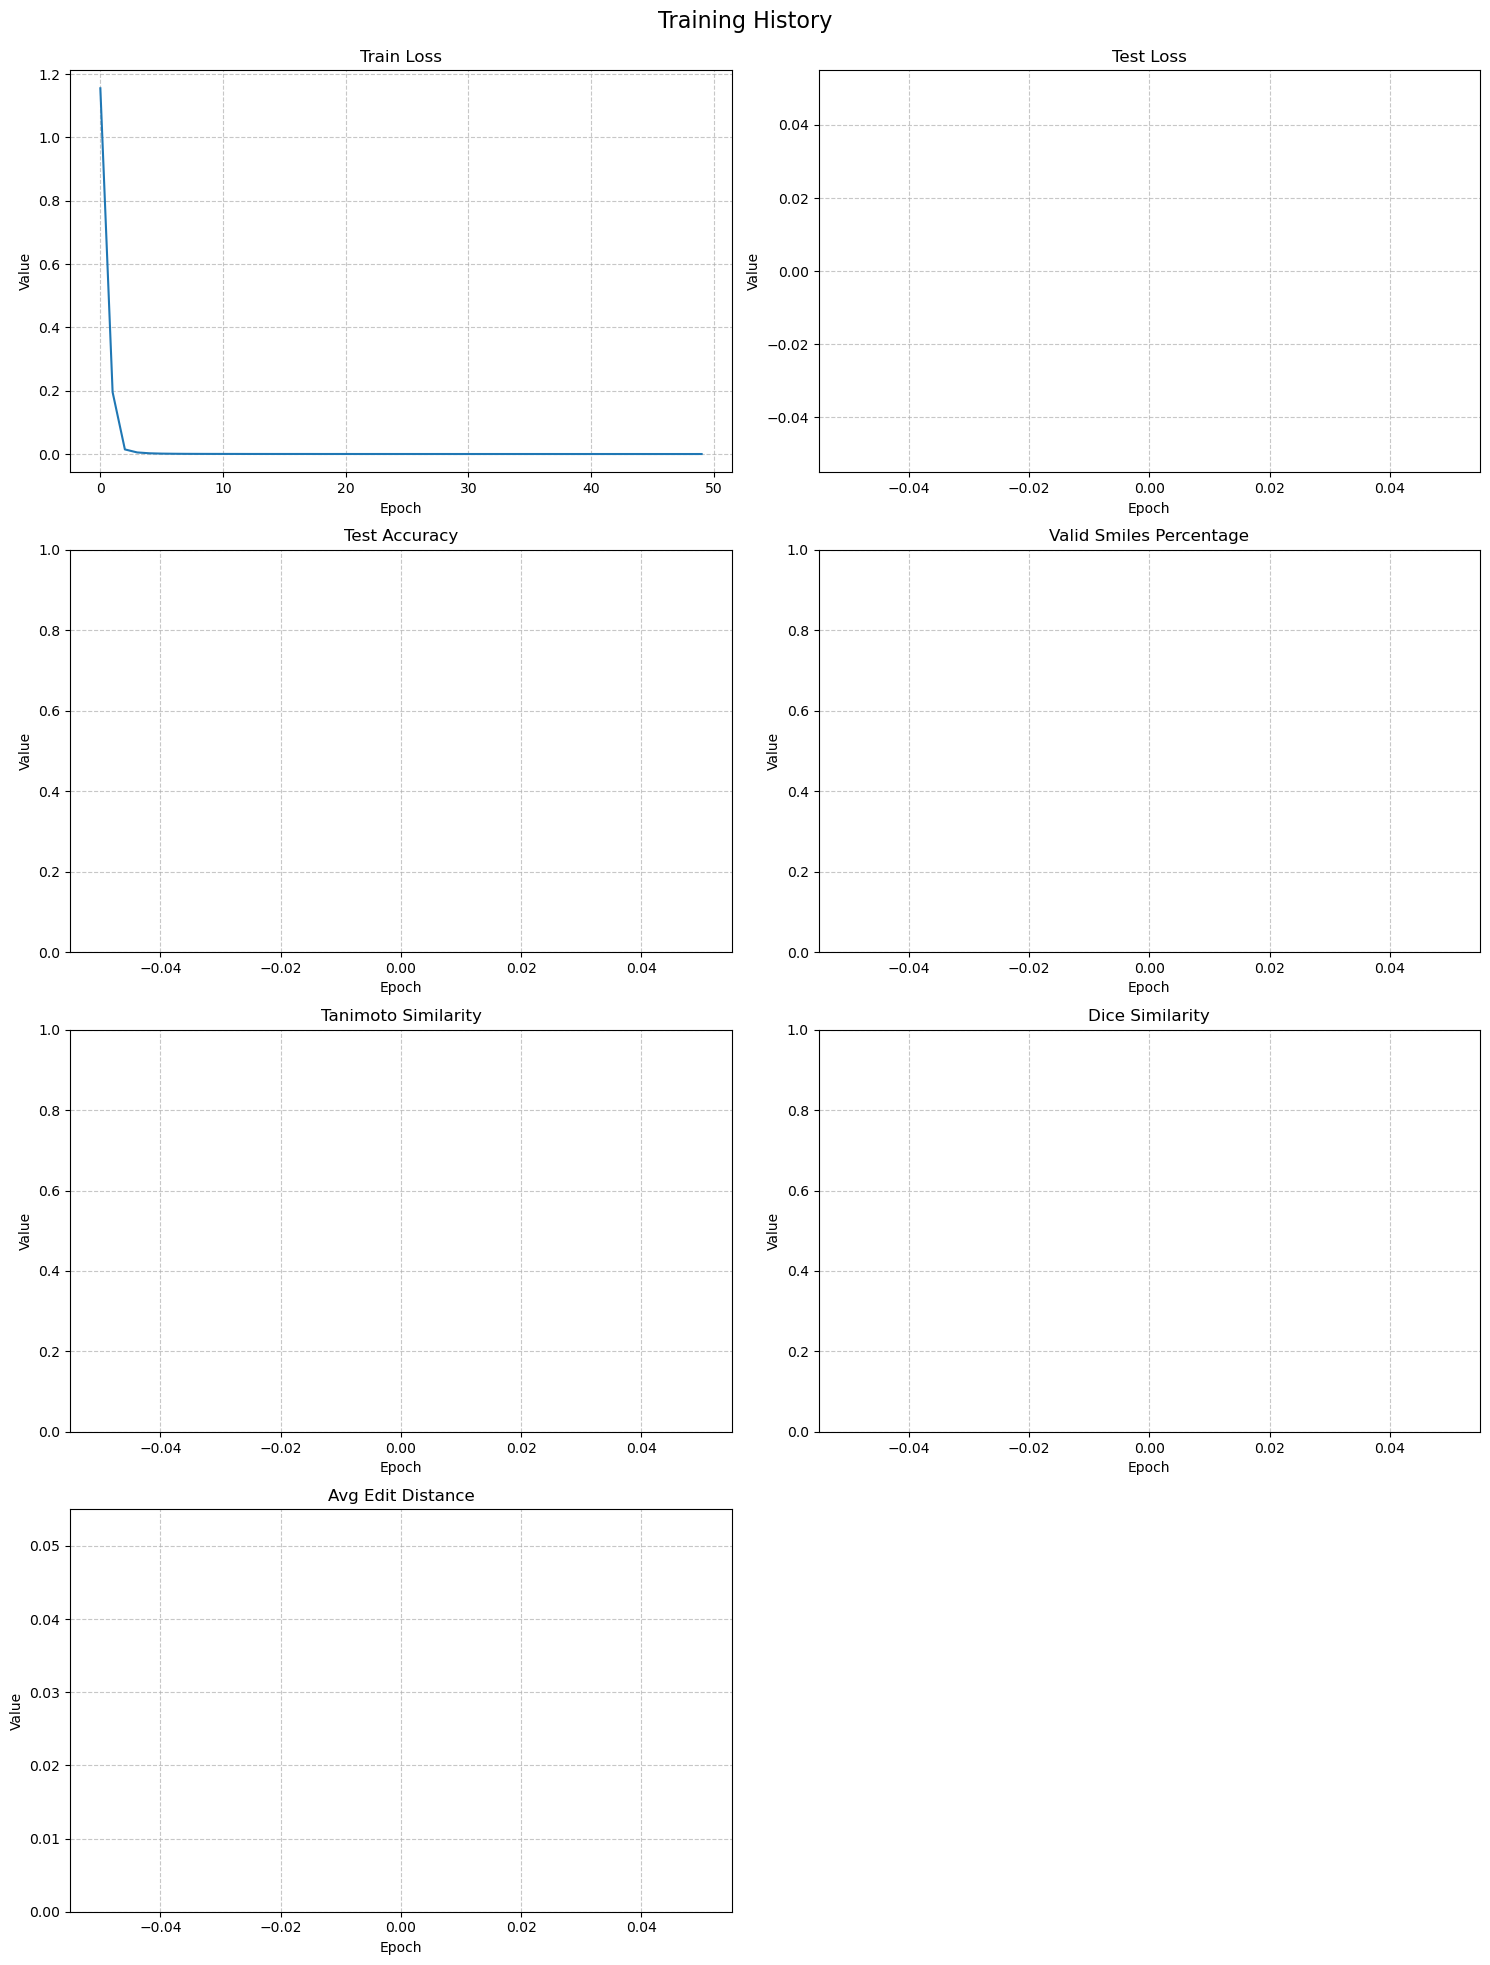

In [21]:
plot_training_history(history)

In [22]:
results

{'test_loss': 5.2482435548141785e-06,
 'valid_smiles_percentage': 100.0,
 'tanimoto_similarity': 0.006611839832080419,
 'dice_similarity': 0.012912420931744911,
 'avg_edit_distance': 55.70764}

In [23]:
history

{'train_loss': {0: 1.1549007035911045,
  1: 0.1953154610623668,
  2: 0.014618113251153907,
  3: 0.005128691344216862,
  4: 0.0024234000983709377,
  5: 0.0013558790697148623,
  6: 0.0009404964646095409,
  7: 0.0006561883586568424,
  8: 0.0005223006744075374,
  9: 0.0004425263685873188,
  10: 0.00039185045164313317,
  11: 0.00037416877505749976,
  12: 0.00028097388678939713,
  13: 0.0002745139467470479,
  14: 0.0002447535148433208,
  15: 0.00022716543328967797,
  16: 0.0002306603393624549,
  17: 0.0002480494074861653,
  18: 0.00017059617175095066,
  19: 0.00019587459622092695,
  20: 0.0002132854474293755,
  21: 0.00016426392055126192,
  22: 0.0001651435878933578,
  23: 0.00018000536155767777,
  24: 0.00014476748267755384,
  25: 0.00017329403004898253,
  26: 0.00014786893472974126,
  27: 0.00014967203994244638,
  28: 0.00017044374064841407,
  29: 0.00011917358125812694,
  30: 0.00015120012371141876,
  31: 0.0001428622219524676,
  32: 0.00014518391525969663,
  33: 0.000144698963843614,
  3